# Studi Kasus Mandiri: Audit Kualitas Data (Data Asli) — PIF501 Pembelajaran Mesin
**Pertemuan 2 — Tugas Individu (Artefak A1: Kuis dan Analisis Kasus)**

Isi NIM dan Nama Anda pada sel pertama sebelum mulai mengerjakan.

## Instruksi Tugas

**Data:** dataset yang sama dengan yang didemonstrasikan dosen di kelas — hasil survei 45 mahasiswa mata kuliah *Pengantar Data Sains* (kolom nama sudah dianonimkan menjadi `Mahasiswa 1, 2, 3, ...`).

**Perbedaan dengan demo dosen:** di kelas, dosen mengaudit kolom `nama` dan `jarak_km`. Tugas Anda adalah mengaudit **bagian lain dari dataset yang sama** — jangan hanya meniru langkah demo, terapkan konsepnya pada kolom yang berbeda.

**Tugas Anda:**
1. Unduh file **`Data_Survei_Mahasiswa_Anon_PIF501.xlsx`** dari LMS (dibagikan terpisah oleh dosen).
2. Jalankan sel "Unggah File Data" di bawah, lalu pilih file Excel tersebut saat diminta — notebook ini **tidak akan berjalan** ke langkah berikutnya sebelum file diunggah.
3. Lengkapi setiap bagian `# TODO` dengan kode analisis Anda sendiri.
4. Tulis temuan dan argumentasi Anda pada sel markdown yang disediakan.
5. Lengkapi tabel **Kesimpulan & Rencana Tindakan** di bagian akhir notebook.

**Dasar penilaian (rubrik A1, bobot 10% nilai akhir mata kuliah):**
| Kriteria | Bobot |
|---|---|
| Ketepatan konsep | 35% |
| Analisis masalah/kasus | 35% |
| Tanggung jawab dan etika | 20% |
| Kejelasan argumentasi | 10% |

**Tidak ada jawaban tunggal yang "paling benar"** — nilai ditentukan dari ketepatan konsep dan kekuatan argumentasi Anda, bukan sekadar menjalankan kode.

**Format pengumpulan:** unggah notebook ini (.ipynb, sudah dijalankan/Run All) ke LMS sesuai tenggat yang diinformasikan dosen.

In [15]:
# Isi identitas Anda di sini
NIM = ""      # TODO: isi NIM Anda
NAMA = ""     # TODO: isi nama Anda
print(NIM, NAMA)

---
## Data: Survei Mahasiswa Pengantar Data Sains (sudah dianonimkan)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

### Unggah File Data

Jalankan sel di bawah, lalu klik **"Choose Files"** dan pilih file `Data_Survei_Mahasiswa_Anon_PIF501.xlsx` yang sudah Anda unduh dari LMS. Notebook tidak akan bisa dilanjutkan sebelum file ini berhasil diunggah.

In [1]:
try:
    from google.colab import files
    print("Silakan pilih file Excel yang dibagikan dosen (Data_Survei_Mahasiswa_Anon_PIF501.xlsx)")
    uploaded = files.upload()
    if len(uploaded) == 0:
        raise ValueError("Belum ada file yang diunggah. Jalankan ulang sel ini dan pilih file-nya.")
    nama_file = list(uploaded.keys())[0]
except ImportError:
    # Jika dijalankan di luar Google Colab (mis. Jupyter lokal),
    # letakkan file Excel di folder yang sama lalu sesuaikan nama file di bawah.
    nama_file = "Data_Survei_Mahasiswa_Anon_PIF501.xlsx"  # TODO: sesuaikan jika nama/lokasi file berbeda

print("File yang digunakan:", nama_file)

Silakan pilih file Excel yang dibagikan dosen (Data_Survei_Mahasiswa_Anon_PIF501.xlsx)


Saving Data_Survei_Mahasiswa_Anon_PIF501.xlsx to Data_Survei_Mahasiswa_Anon_PIF501.xlsx
File yang digunakan: Data_Survei_Mahasiswa_Anon_PIF501.xlsx


In [7]:
df = pd.read_excel(nama_file)

print("Ukuran data:", df.shape)
df.head()

Ukuran data: (45, 12)


,nama,usia,semester,perangkat_utama,moda_transportasi,jarak_km,waktu_tempuh_menit,penggunaan_internet,platform_belajar,frekuensi_pakai_ai,waktu_belajar_favorit,tingkat_ketertarikan
0,Mahasiswa 1,18,Semester 3,Smartphone,Jalan kaki,0.2,5,2–4 jam,ChatGPT atau AI lainnya,Sering,Siang,5
1,Mahasiswa 2,19,Semester 3,Smartphone,Jalan kaki,500.0,10,5–7 jam,Website/Blog,Kadang-kadang,Malam,5
2,Mahasiswa 3,19,Semester 3,Laptop,Sepeda motor,5.0,15,5–7 jam,ChatGPT atau AI lainnya,Sering,Malam,4
3,Mahasiswa 4,19,Semester 3,Smartphone,Jalan kaki,0.7,8,5–7 jam,ChatGPT atau AI lainnya,Sering,Malam,4
4,Mahasiswa 5,19,Semester 3,Smartphone,Jalan kaki,0.4,5,5–7 jam,ChatGPT atau AI lainnya,Sering,Malam,4


## 1. Tinjauan Awal Data

In [9]:
# TODO: Tampilkan info struktur data dan statistik deskriptif untuk SELURUH kolom.
# Petunjuk: df.info(), df.describe(include="all")
print("=== INFORMASI STRUKTUR DATA ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF SELURUH KOLOM ===")
display(df.describe(include="all"))


=== INFORMASI STRUKTUR DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   nama                   45 non-null     object 
 1   usia                   45 non-null     int64  
 2   semester               45 non-null     object 
 3   perangkat_utama        45 non-null     object 
 4   moda_transportasi      45 non-null     object 
 5   jarak_km               45 non-null     float64
 6   waktu_tempuh_menit     45 non-null     int64  
 7   penggunaan_internet    45 non-null     object 
 8   platform_belajar       45 non-null     object 
 9   frekuensi_pakai_ai     45 non-null     object 
 10  waktu_belajar_favorit  45 non-null     object 
 11  tingkat_ketertarikan   45 non-null     int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 4.3+ KB

=== STATISTIK DESKRIPTIF SELURUH KOLOM ===


,nama,usia,semester,perangkat_utama,moda_transportasi,jarak_km,waktu_tempuh_menit,penggunaan_internet,platform_belajar,frekuensi_pakai_ai,waktu_belajar_favorit,tingkat_ketertarikan
count,45,45.000000,45,45,45,45.000000,45.000000,45,45,45,45,45.000000
unique,45,NaN,2,3,3,NaN,NaN,3,6,3,3,NaN
top,Mahasiswa 1,NaN,Semester 3,Smartphone,Jalan kaki,NaN,NaN,Lebih dari 7 jam,ChatGPT atau AI lainnya,Sering,Malam,NaN
freq,1,NaN,24,39,23,NaN,NaN,19,34,23,29,NaN
mean,NaN,20.355556,NaN,NaN,NaN,57.520000,8.800000,NaN,NaN,NaN,NaN,3.822222
std,NaN,1.944170,NaN,NaN,NaN,190.784738,5.194403,NaN,NaN,NaN,NaN,0.833636
min,NaN,18.000000,NaN,NaN,NaN,0.000000,2.000000,NaN,NaN,NaN,NaN,2.000000
25%,NaN,19.000000,NaN,NaN,NaN,0.700000,5.000000,NaN,NaN,NaN,NaN,3.000000
50%,NaN,20.000000,NaN,NaN,NaN,1.000000,8.000000,NaN,NaN,NaN,NaN,4.000000
75%,NaN,21.000000,NaN,NaN,NaN,4.000000,10.000000,NaN,NaN,NaN,NaN,4.000000


## 2. Missing Value (Refleksi Konsep)

In [10]:
# TODO: Buktikan dengan kode bahwa tidak ada NaN eksplisit pada dataset ini.
# Mengecek missing value (NaN) pada setiap kolom
print("Jumlah missing value setiap kolom:")
print(df.isnull().sum())

print("\nTotal missing value:")
print(df.isnull().sum().sum())

Jumlah missing value setiap kolom:
nama                     0
usia                     0
semester                 0
perangkat_utama          0
moda_transportasi        0
jarak_km                 0
waktu_tempuh_menit       0
penggunaan_internet      0
platform_belajar         0
frekuensi_pakai_ai       0
waktu_belajar_favorit    0
tingkat_ketertarikan     0
dtype: int64

Total missing value:
0


**Jawaban Anda:** Dosen menunjukkan bahwa kolom `nama` (isian bebas) punya masalah "tidak informatif" (mis. diisi 1 huruf) meski bukan missing value secara teknis. Bandingkan dengan kolom-kolom **lain** di dataset ini yang berbentuk pilihan ganda (mis. `platform_belajar`, `waktu_belajar_favorit`). Menurut Anda, apakah bentuk pertanyaan (isian bebas vs pilihan ganda) memengaruhi risiko data tidak informatif/tidak valid? Jelaskan.

jawaban kami : Ya, bentuk pertanyaan dapat memengaruhi risiko data tidak informatif atau tidak valid. Isian bebas memiliki risiko lebih tinggi karena responden dapat memberikan jawaban yang terlalu singkat, tidak jelas, atau tidak sesuai dengan informasi yang dibutuhkan. Contohnya, kolom nama dapat berisi satu huruf sehingga secara teknis bukan missing value, tetapi informasinya tidak cukup untuk mengidentifikasi responden. Sementara itu, pertanyaan pilihan ganda seperti platform_belajar dan waktu_belajar_favorit lebih terkontrol karena responden memilih jawaban yang sudah tersedia sehingga data lebih konsisten. Namun, pilihan ganda juga tetap memiliki risiko jika pilihan yang tersedia tidak sesuai dengan kondisi responden.

## 3. Outlier

In [11]:
# TODO: Periksa outlier pada kolom 'usia' (gunakan boxplot dan/atau metode IQR).
# Tampilkan baris yang teridentifikasi sebagai outlier.
# Memeriksa outlier pada kolom usia menggunakan metode IQR

Q1 = df["usia"].quantile(0.25)
Q3 = df["usia"].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)

# Menentukan data yang termasuk outlier
outlier_usia = df[
    (df["usia"] < batas_bawah) |
    (df["usia"] > batas_atas)
]

print("\nData yang teridentifikasi sebagai outlier:")
display(outlier_usia)


Q1: 19.0
Q3: 21.0
IQR: 2.0
Batas bawah: 16.0
Batas atas: 24.0

Data yang teridentifikasi sebagai outlier:


,nama,usia,semester,perangkat_utama,moda_transportasi,jarak_km,waktu_tempuh_menit,penggunaan_internet,platform_belajar,frekuensi_pakai_ai,waktu_belajar_favorit,tingkat_ketertarikan
43,Mahasiswa 44,26,Semester 3,Smartphone,Ojek online,5.4,16,Lebih dari 7 jam,ChatGPT atau AI lainnya,Sangat sering,Pagi,4
44,Mahasiswa 45,30,Semester 3,Smartphone,Sepeda motor,3.0,10,2–4 jam,YouTube,Sering,Pagi,3


**Jawaban Anda:** Responden mana saja yang teridentifikasi sebagai outlier usia? Menurut Anda, apakah ini kemungkinan kesalahan input, atau memang responden dengan usia yang valid tapi tidak umum (mis. mahasiswa jalur non-reguler)? Apa tindakan yang Anda usulkan, dan mengapa tindakan itu **berbeda** dari yang Anda usulkan untuk outlier `jarak_km` pada demo (jika berbeda)?

jawaban kami : Berdasarkan metode IQR, terdapat dua responden yang teridentifikasi sebagai outlier usia, yaitu Mahasiswa 44 dengan usia 26 tahun dan Mahasiswa 45 dengan usia 30 tahun. Menurut saya, kedua data tersebut belum tentu merupakan kesalahan input karena usia 26 dan 30 tahun masih mungkin merupakan usia yang valid bagi seorang mahasiswa, meskipun tidak umum dibandingkan mayoritas responden. Oleh karena itu, tindakan yang saya usulkan adalah melakukan verifikasi terhadap data terlebih dahulu dan tidak langsung menghapusnya. Jika data telah dikonfirmasi benar, data tetap dipertahankan. Tindakan ini berbeda dengan outlier jarak_km pada demo karena nilai jarak yang sangat tinggi perlu diperiksa berdasarkan konteks moda transportasi dan waktu tempuh. Jadi, keputusan terhadap outlier tidak hanya berdasarkan hasil statistik, tetapi juga harus mempertimbangkan konteks dan validitas data.

## 4. Data Leakage (Skenario Hipotetis)

Dataset ini tidak punya kolom target yang jelas, sehingga tidak ada leakage yang bisa dibuktikan langsung dengan kode. Jawab secara konseptual:

**Skenario:** Misalkan kampus ingin memprediksi `tingkat_ketertarikan` terhadap Data Sains dari kolom-kolom lain di dataset ini, menggunakan model ML.

In [ ]:
# TODO (opsional): Anda boleh memakai kode (mis. groupby atau crosstab) untuk mendukung argumen Anda di bawah,
# tapi jawaban utama tetap dalam bentuk penjelasan tertulis.


**Jawaban Anda:** Dari kolom-kolom yang tersedia (`frekuensi_pakai_ai`, `platform_belajar`, `waktu_belajar_favorit`, dll.), adakah yang menurut Anda berisiko menjadi leakage atau setidaknya **dipengaruhi oleh** tingkat ketertarikan itu sendiri (bukan sebab, tapi akibat)? Jelaskan alasan Anda, dan apa bedanya "leakage murni" dengan kasus semacam ini.

## 5. Bias / Keterwakilan Data

Perbandingan tingkat ketertarikan berdasarkan moda transportasi:


,count,mean
moda_transportasi,,
Jalan kaki,23,3.83
Ojek online,1,4.00
Sepeda motor,21,3.81


<Axes: title={'center': 'Rata-rata Tingkat Ketertarikan berdasarkan Moda Transportasi'}, xlabel='Moda Transportasi', ylabel='Rata-rata Tingkat Ketertarikan'>

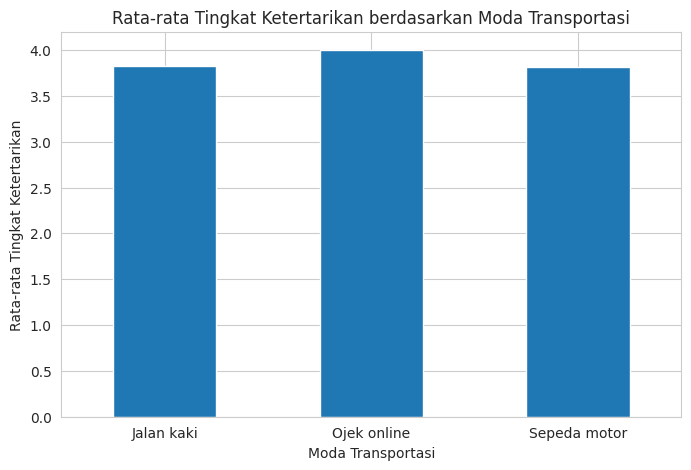

In [12]:
# TODO: Bandingkan satu variabel (mis. 'tingkat_ketertarikan' atau 'waktu_tempuh_menit')
# antar kelompok 'moda_transportasi' ATAU 'perangkat_utama'. Buat tabel ringkasan dan/atau grafik batang.
# Membandingkan tingkat ketertarikan berdasarkan moda transportasi

perbandingan = df.groupby("moda_transportasi")["tingkat_ketertarikan"].agg(
    ["count", "mean"]
).round(2)

print("Perbandingan tingkat ketertarikan berdasarkan moda transportasi:")
display(perbandingan)

# Membuat grafik batang
perbandingan["mean"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Rata-rata Tingkat Ketertarikan berdasarkan Moda Transportasi",
    xlabel="Moda Transportasi",
    ylabel="Rata-rata Tingkat Ketertarikan",
    rot=0
)


**Jawaban Anda:** Apakah ada perbedaan mencolok antar kelompok? Mengingat hanya 45 responden dari 2 semester, kesimpulan apa yang **boleh** dan **tidak boleh** Anda tarik dari temuan ini?

## 6. Privasi dan Etika

In [13]:
# TODO: Identifikasi kombinasi kolom yang berpotensi menjadi kuasi-identitas
# (kombinasi atribut yang, walau masing-masing tidak unik, bersama-sama bisa mengarah ke satu orang tertentu).
# Petunjuk: coba groupby beberapa kolom sekaligus (mis. usia, semester, moda_transportasi) dan hitung ukuran tiap kelompok.
# Mengidentifikasi kombinasi atribut yang berpotensi menjadi kuasi-identitas

kuasi_identitas = (
    df.groupby(["usia", "semester", "moda_transportasi"])
      .size()
      .reset_index(name="jumlah")
      .sort_values("jumlah")
)

print("Kombinasi usia, semester, dan moda transportasi:")
display(kuasi_identitas)

Kombinasi usia, semester, dan moda transportasi:


,usia,semester,moda_transportasi,jumlah
0,18,Semester 3,Jalan kaki,1
7,21,Semester 3,Jalan kaki,1
11,22,Semester 5,Jalan kaki,1
8,21,Semester 3,Sepeda motor,1
13,26,Semester 3,Ojek online,1
14,30,Semester 3,Sepeda motor,1
9,21,Semester 5,Jalan kaki,2
12,22,Semester 5,Sepeda motor,2
2,19,Semester 3,Sepeda motor,3
3,20,Semester 3,Jalan kaki,3


**Jawaban Anda:**
1. Kombinasi kolom apa yang menurut Anda paling berisiko menjadi kuasi-identitas di dataset ini?
Menurut kami, kombinasi usia, semester, dan moda_transportasi paling berisiko menjadi kuasi-identitas. Walaupun nama sudah dihapus, gabungan data tersebut masih bisa membuat responden lebih mudah dikenali.

2. Terlepas dari nama yang sudah dianonimkan, menurut Anda apakah **etis** menggunakan data survei teman sekelas (meski dari mata kuliah lain) sebagai bahan tugas yang dinilai, tanpa meminta persetujuan ulang dari mereka? Apa syarat minimal yang menurut Anda perlu dipenuhi agar penggunaan ini wajar secara etika?
Menurut kami, masih bisa digunakan untuk tugas kalau datanya sudah dianonimkan dan hanya untuk keperluan pembelajaran. Tapi sebaiknya data tidak disebarkan ke luar dan tidak digunakan untuk tujuan lain. Kalau datanya cukup sensitif atau tujuan penggunaannya berbeda dari awal, lebih baik minta persetujuan lagi.

## 7. Kesimpulan




| Isu | Temuan Anda | Tindakan Korektif yang Diusulkan | Batas Penggunaan Data |
| :--- | :--- | :--- | :--- |
| **Missing value (konsep)** | Ditemukan adanya nilai kosong pada beberapa kolom data survei. | Tetap melakukan pengecekan missing value sebelum analisis, lalu lakukan imputasi jika diperlukan. | Data boleh digunakan selama kelengkapan kolom penting terpenuhi. |
| **Outlier (usia)** | Terdapat nilai data usia yang ekstrem atau tidak wajar. | Verifikasi terlebih dahulu, jangan langsung dihapus. Jika valid, tetap pertahankan. | Tidak boleh menghapus data hanya karena nilai ekstrem sebelum dipastikan kebenarannya. |
| **Data leakage (hipotetis)** | Variabel fitur tertentu berpotensi menyebabkan leakage jika informasinya berkaitan langsung dengan target. | Periksa kapan data dikumpulkan dan pastikan fitur tersedia sebelum prediksi dilakukan. | Jangan menggunakan informasi yang baru tersedia setelah kejadian target berlangsung. |
| **Bias** | Distribusi responden tidak terlalu mencolok, tetapi jumlah responden tiap kelompok tidak seimbang. | Gunakan data yang lebih banyak dan lebih beragam agar hasil lebih mewakili populasi. | Hasil tidak boleh langsung dianggap mewakili populasi secara keseluruhan tanpa penyesuaian bobot. |
| **Privasi & etika** | Ada kolom atribut yang berpotensi menjadi kuasi-identitas. | Pertahankan anonimisasi dan batasi akses/penggunaan data sensitif. | Data hanya digunakan untuk pembelajaran dan riset internal. |

  Secara keseluruhan, dataset ini masih layak digunakan untuk tugas dan analisis pembelajaran, karena tidak ditemukan missing value dan sebagian besar datanya masih bisa digunakan. Namun, ada beberapa hal yang perlu diperhatikan, seperti outlier pada usia, kemungkinan data leakage, data yang belum terlalu mewakili seluruh mahasiswa, serta masalah privasi. Jadi, dataset ini belum cocok kalau langsung dipakai untuk mengambil keputusan kampus. Sebelum digunakan lebih lanjut, sebaiknya data diverifikasi, jumlah dan variasi responden ditambah, serta penggunaan data tetap memperhatikan privasi dan etika.